# Model Analysis

End-to-end evaluation notebook for the 3-class workload classifier.
Each trained model is assessed in two forms:
- **Keras** (`.keras`) — full-precision evaluation via `tf.keras`
- **TFLite** (`.tflite`) — quantised/converted evaluation via the TFLite interpreter

Metrics reported for every model:
- Classification report (precision, recall, F1-score per class)
- Confusion matrix (colour-coded heatmap)

**Classes:** `Low Activity` | `High Computational` | `Network Intensive`

## Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## Load Test Data

Load the training split CSV and preview the first few rows.

In [2]:
# Load the dataset used for evaluation
df_train = pd.read_csv('../split/test.csv')
df_train.head()


,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,45.0,70.0,30.1,-258.0,3.906493,3.535838,0
1,50.0,72.0,32.0,-182.0,0.000000,0.000000,0
2,42.0,77.0,33.4,-386.0,6.626622,0.888801,1
3,55.0,74.0,31.5,-258.0,0.966595,0.157534,0
4,67.0,80.0,34.8,-386.0,0.410404,0.533355,1


Separate features (`X_test`) from the ground-truth labels (`y_test`).
The `Target` column holds integer-encoded class labels (0 = Low Activity,
1 = High Computational, 2 = Network Intensive).

In [3]:
# Drop the label column to get the feature matrix
X_test = df_train.drop('Target', axis=1)

# Ground-truth labels for metric computation
y_test = df_train['Target']


## Evaluation Helpers

Two helper functions handle evaluation for the two model formats:
- `evaluate_model` — wraps a standard Keras model
- `tflite_predict` + `evaluate_model_tflite` — wraps a TFLite interpreter,
  running inference sample-by-sample (required because the TFLite runtime
  does not support dynamic batch sizes by default)

In [4]:
def evaluate_model(model, model_name):
    """Evaluate a Keras model and display a classification report and confusion matrix.

    Runs full-batch prediction on the global X_test feature matrix, derives
    hard class labels via argmax, then prints sklearn's classification report
    and renders a colour-coded confusion matrix.

    Args:
        model: A compiled tf.keras.Model with a predict() method.
        model_name (str): Label shown in the confusion matrix title.
    """
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    # Predict class probabilities, then convert to hard labels
    y_prob = model.predict(X_test)
    y_predict = np.argmax(y_prob, axis=1)

    title = 'Confusion Matrix - ' + model_name

    print('\nClassification Report\n')
    print(classification_report(y_test, y_predict, target_names=class_name))

    # Plot confusion matrix heatmap
    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


In [5]:
def tflite_predict(interpreter, X):
    """Run inference on a TFLite interpreter one sample at a time.

    The TFLite runtime requires a fixed input shape, so each sample is fed
    individually as a (1, n_features) float32 tensor. Outputs are collected
    and stacked into a single probability array.

    Args:
        interpreter (tf.lite.Interpreter): An allocated TFLite interpreter.
        X (array-like): Feature matrix, shape (n_samples, n_features).

    Returns:
        np.ndarray: Predicted probability array, shape (n_samples, n_classes).
    """
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    outputs = []

    for i in range(len(X)):
        # Reshape to (1, n_features) and cast to float32 as required by TFLite
        x = X[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()  # Run inference for this single sample

        y = interpreter.get_tensor(output_details[0]['index'])
        outputs.append(y[0])

    return np.array(outputs)


In [6]:
def evaluate_model_tflite(interpreter, model_name):
    """Evaluate a TFLite model and display a classification report and confusion matrix.

    Uses tflite_predict() to run sample-by-sample inference, then follows the
    same reporting pipeline as evaluate_model().

    Args:
        interpreter (tf.lite.Interpreter): An allocated TFLite interpreter.
        model_name (str): Label shown in the confusion matrix title.
    """
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    # Predict class probabilities via the TFLite runtime, then take argmax
    y_prob = tflite_predict(interpreter, X_test)
    y_predict = np.argmax(y_prob, axis=1)

    title = 'Confusion Matrix - ' + model_name

    print('\nClassification Report\n')
    print(classification_report(y_test, y_predict, target_names=class_name))

    # Plot confusion matrix heatmap
    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


---
## ANN Evaluation

Load and evaluate the Artificial Neural Network in both Keras and TFLite forms.

In [7]:
# Load the trained ANN Keras model and print its architecture summary
model = tf.keras.models.load_model('../model/ANN.keras')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227 (4.80 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 776 (3.04 KB)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step

Classification Report

                    precision    recall  f1-score   support

      Low Activity       1.00      0.96      0.98      3562
High Computational       0.96      0.98      0.97      2246
 Network Intensive       0.93      0.99      0.96      1169

          accuracy                           0.97      6977
         macro avg       0.96      0.98      0.97      6977
      weighted avg       0.98      0.97      0.98      6977



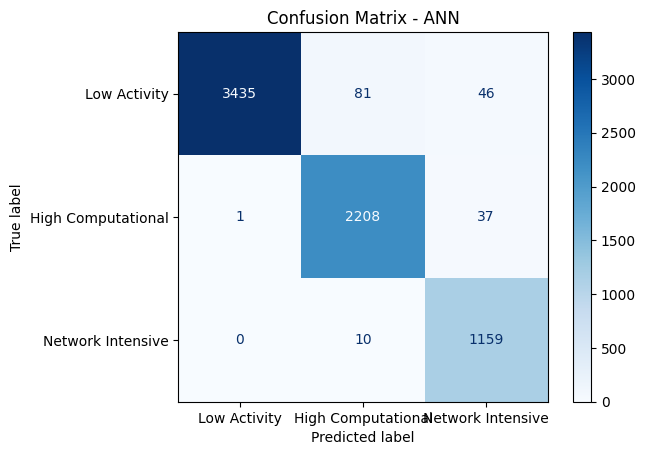

In [8]:
# Evaluate the full-precision Keras ANN
evaluate_model(model, 'ANN')


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Classification Report

                    precision    recall  f1-score   support

      Low Activity       1.00      0.96      0.98      3562
High Computational       0.96      0.98      0.97      2246
 Network Intensive       0.93      0.99      0.96      1169

          accuracy                           0.97      6977
         macro avg       0.96      0.98      0.97      6977
      weighted avg       0.98      0.97      0.98      6977



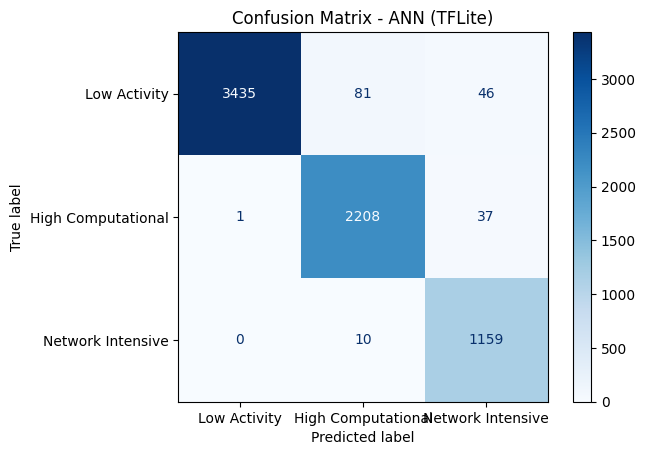

In [9]:
# Load the converted TFLite ANN and allocate memory for its tensors
interpreter = tf.lite.Interpreter(model_path='../model/tflite/ANN.tflite')
interpreter.allocate_tensors()

# Evaluate the TFLite ANN — compare results to the Keras version above
evaluate_model_tflite(interpreter, 'ANN (TFLite)')


---
## Logistic Regression Evaluation

Load and evaluate the Logistic Regression model in both Keras and TFLite forms.

In [10]:
# Load the trained Logistic Regression Keras model and print its architecture summary
model = tf.keras.models.load_model('../model/LR.keras')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (264.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44 (180.00 B)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step

Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.87      0.90      0.89      3562
High Computational       0.82      0.78      0.80      2246
 Network Intensive       0.94      0.93      0.93      1169

          accuracy                           0.87      6977
         macro avg       0.88      0.87      0.87      6977
      weighted avg       0.87      0.87      0.87      6977



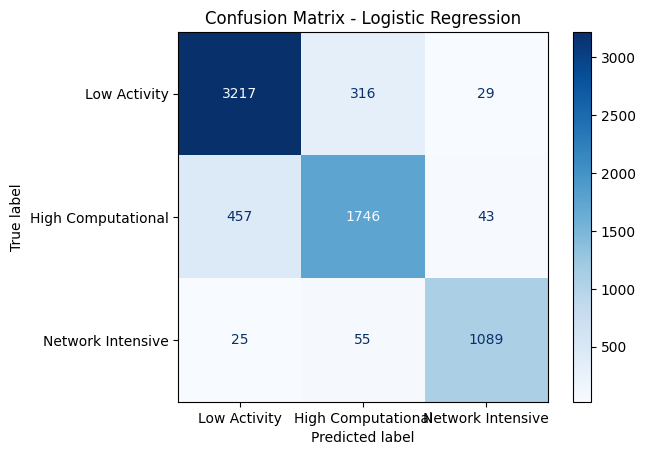

In [11]:
# Evaluate the full-precision Keras Logistic Regression model
evaluate_model(model, 'Logistic Regression')


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.87      0.90      0.89      3562
High Computational       0.82      0.78      0.80      2246
 Network Intensive       0.94      0.93      0.93      1169

          accuracy                           0.87      6977
         macro avg       0.88      0.87      0.87      6977
      weighted avg       0.87      0.87      0.87      6977



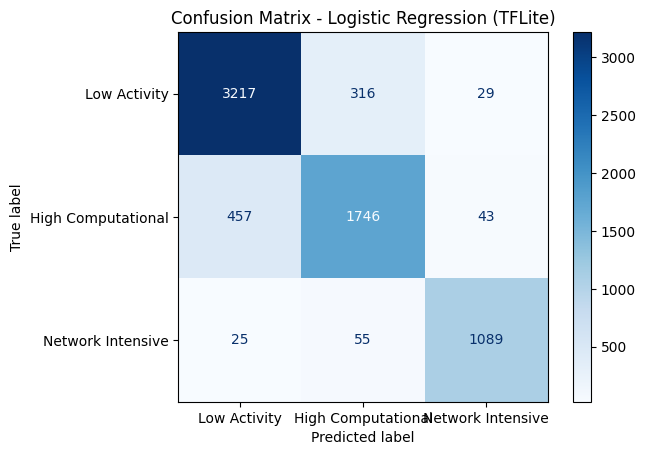

In [12]:
# Load the converted TFLite Logistic Regression model and allocate tensors
interpreter = tf.lite.Interpreter(model_path='../model/tflite/LR.tflite')
interpreter.allocate_tensors()

# Evaluate the TFLite Logistic Regression — compare results to the Keras version above
evaluate_model_tflite(interpreter, 'Logistic Regression (TFLite)')
